In [99]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and filter data
df = pd.read_csv('house_prices.csv')
df.fillna({'price': 0, 'bedrooms': 0, 'sqft_living': 0, 'sqft_lot': 0, 'sqft_above': 0, 'bathrooms': 0}, inplace=True)
mask = df['bedrooms'].isin([3, 4, 5])
filtered_df = df[mask]

In [100]:
# Features and target
X = filtered_df[['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']] #Features
y = filtered_df['price'] #target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [101]:
# Train model
lr_model = LinearRegression() #Multi Feature Predictions Model
lr_model.fit(X_train, y_train)
print(f"Model R² Score: {lr_model.score(X_test, y_test):.2f}")

Model R² Score: 0.24


In [102]:
# Predict and evaluate Linear Regression Model Multi Feature 
lr_y_pred = lr_model.predict(X_test)
print(f"First 5 predictions: {lr_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
lr_errors = y_test.values - lr_y_pred
print(f"First 5 prediction errors: {lr_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(lr_errors)):.1f}")


First 5 predictions: [635030.92273903 261967.643622   793917.48659734 688975.31150258
 405084.16518146]
First 5 actual prices: [522500.  148612.5 409124.  800000.  275000. ]
First 5 prediction errors: [-112530.92273903 -113355.143622   -384793.48659734  111024.68849742
 -130084.16518146]
Mean Absolute Error: 207827.2


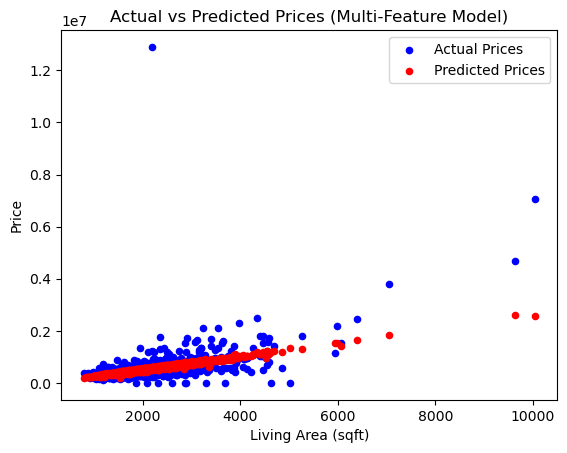

In [103]:
# Visualize predictions Multi-Feature (using sqft_living for x-axis)
lr_plot_df = pd.DataFrame({
    'sqft_living': X_test['sqft_living'],
    'actual_price': y_test,
    'predicted_price': lr_y_pred
})
lr_ax = lr_plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
lr_plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='red', label='Predicted Prices', ax=lr_ax)
lr_ax.set_xlabel('Living Area (sqft)')
lr_ax.set_ylabel('Price')
lr_ax.set_title('Actual vs Predicted Prices (Multi-Feature Model)')
plt.savefig('multi_feature_predictions.png')
plt.show()


In [104]:
# Check correlation to optimize features
print(filtered_df[['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']].corr())

             bedrooms  sqft_living  sqft_lot  sqft_above  bathrooms
bedrooms     1.000000     0.506783  0.060007    0.396644   0.407246
sqft_living  0.506783     1.000000  0.189063    0.859999   0.730799
sqft_lot     0.060007     0.189063  1.000000    0.197151   0.086993
sqft_above   0.396644     0.859999  0.197151    1.000000   0.651438
bathrooms    0.407246     0.730799  0.086993    0.651438   1.000000


In [105]:
# Train model Decision Tree Regressor
dtr_model = DecisionTreeRegressor(random_state=42) #Decision Tree Prediction Model
dtr_model.fit(X_train, y_train)
print(f"Decision Tree R² Score: {dtr_model.score(X_test, y_test):.2f}")



Decision Tree R² Score: -2.28


In [106]:
#Predict and evaluate Decision Tree Regressor
dtr_y_pred = dtr_model.predict(X_test)
print(f"First 5 predictions: {dtr_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
dtr_errors = y_test.values - dtr_y_pred
print(f"First 5 prediction errors: {dtr_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(dtr_errors)):.1f}")

First 5 predictions: [ 770000.  325000. 1110000.  550000.  466800.]
First 5 actual prices: [522500.  148612.5 409124.  800000.  275000. ]
First 5 prediction errors: [-247500.  -176387.5 -700876.   250000.  -191800. ]
Mean Absolute Error: 307890.7


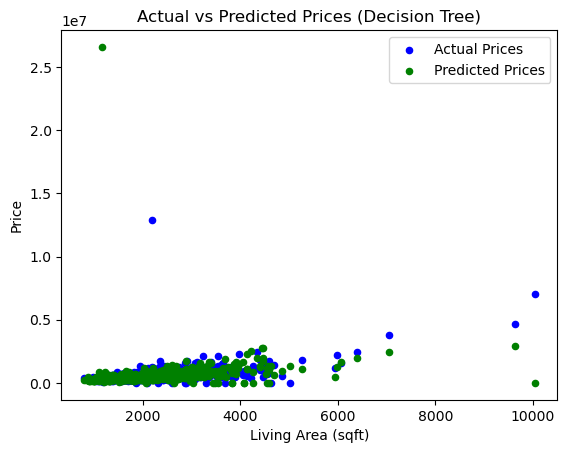

In [107]:
# Visualize predictions Decision Tree (using sqft_living for x-axis) 
dtr_plot_df = pd.DataFrame({
        'sqft_living': X_test['sqft_living'],
        'actual_price': y_test,
        'predicted_price': dtr_y_pred
         })
dtr_ax = dtr_plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
dtr_plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='green', label='Predicted Prices', ax=dtr_ax)
dtr_ax.set_xlabel('Living Area (sqft)')
dtr_ax.set_ylabel('Price')
dtr_ax.set_title('Actual vs Predicted Prices (Decision Tree)')
plt.savefig('decision_tree_predictions.png')
plt.show()

In [108]:
# Scale features (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [109]:
# Train KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
print(f"KNN R² Score: {knn_model.score(X_test_scaled, y_test):.2f}")

KNN R² Score: 0.01


In [110]:
# Predict and evaluate
knn_y_pred = knn_model.predict(X_test_scaled)
print(f"First 5 predictions: {knn_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
knn_errors = y_test.values - knn_y_pred
print(f"First 5 prediction errors: {knn_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(knn_errors)):.1f}")

First 5 predictions: [ 481338.         251400.        1246716.4        527400.
  526126.6666666]
First 5 actual prices: [522500.  148612.5 409124.  800000.  275000. ]
First 5 prediction errors: [  41162.        -102787.5       -837592.4        272600.
 -251126.6666666]
Mean Absolute Error: 233915.5


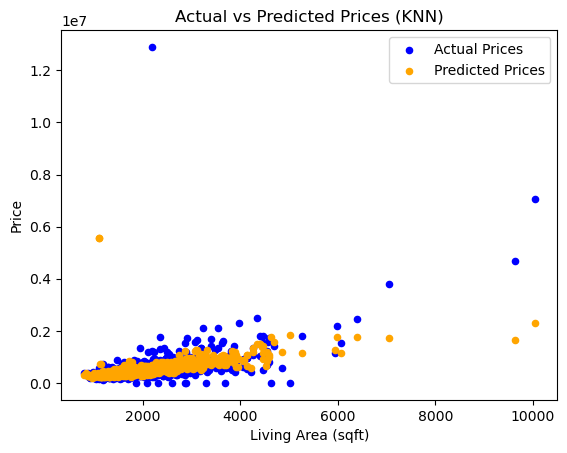

In [111]:
# Visualize predictions (using sqft_living for x-axis)
knn_plot_df = pd.DataFrame({
         'sqft_living': X_test['sqft_living'],  # Use original (unscaled) for plotting
         'actual_price': y_test,
         'predicted_price': knn_y_pred
     })
knn_ax = knn_plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
knn_plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='orange', label='Predicted Prices', ax=knn_ax)
knn_ax.set_xlabel('Living Area (sqft)')
knn_ax.set_ylabel('Price')
knn_ax.set_title('Actual vs Predicted Prices (KNN)')
plt.savefig('knn_predictions.png')
plt.show()

In [112]:
# Compare model performance
print("\nModel Performance Comparison:")
print(f"Linear Regression R²: {lr_model.score(X_test, y_test):.2f}, MAE: {np.mean(np.abs(lr_errors)):.1f}")
print(f"Decision Tree R²: {dtr_model.score(X_test, y_test):.2f}, MAE: {np.mean(np.abs(dtr_errors)):.1f}")
print(f"KNN R²: {knn_model.score(X_test_scaled, y_test):.2f}, MAE: {np.mean(np.abs(knn_errors)):.1f}")


Model Performance Comparison:
Linear Regression R²: 0.24, MAE: 207827.2
Decision Tree R²: -2.28, MAE: 307890.7
KNN R²: 0.01, MAE: 233915.5


In [113]:
# Calculate feature importance
features = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']
importance = dtr_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importance})
print("\nFeature Importance:")
print(feature_importance.sort_values(by='Importance', ascending=False))

  


Feature Importance:
       Feature  Importance
2     sqft_lot    0.400818
4    bathrooms    0.280459
1  sqft_living    0.190708
3   sqft_above    0.113046
0     bedrooms    0.014969


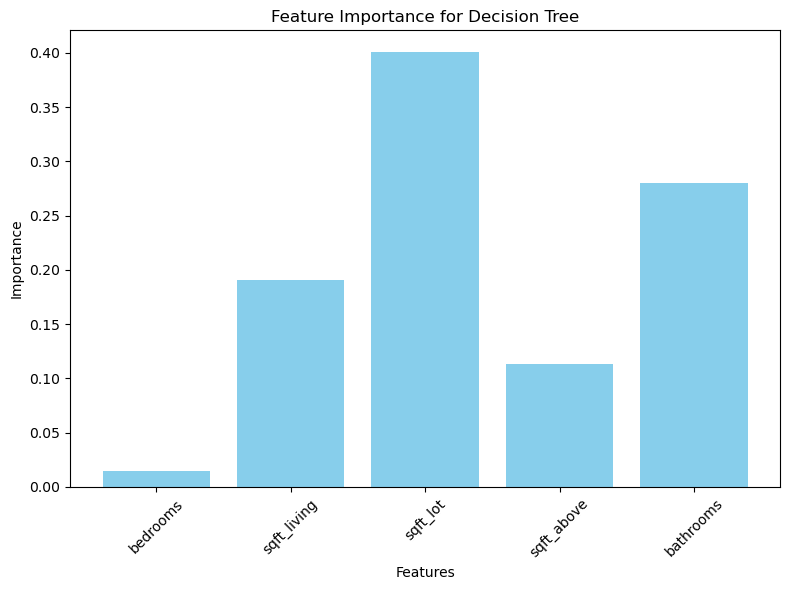

In [114]:
# Visualize feature importance
plt.figure(figsize=(8, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance for Decision Tree')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()


In [115]:
# Example: Exclude low-importance feature (e.g., sqft_lot)
exclude_sqft_lot_features = ['bedrooms', 'sqft_living', 'sqft_above', 'bathrooms']  # Adjust based on output
X = filtered_df[exclude_sqft_lot_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
xsqftlotdtr_model = DecisionTreeRegressor(random_state=42)
xsqftlotdtr_model.fit(X_train, y_train)
print(f"Refined Decision Tree R² Score: {xsqftlotdtr_model.score(X_test, y_test):.2f}")
xsqftlotdtr_y_pred = xsqftlotdtr_model.predict(X_test)
xsqftlotdtr_errors = y_test.values - xsqftlotdtr_y_pred 
print(f"Refined MAE: {np.mean(np.abs(xsqftlotdtr_errors)):.1f}")

Refined Decision Tree R² Score: -2.29
Refined MAE: 311158.0


In [116]:
# Define parameter grid for decision tree
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [117]:
# Grid search with cross-validation
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

In [118]:
# Best model
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.2f}")


Best Parameters: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV R² Score: 0.29


In [119]:
# Evaluate on test set
best_y_pred = best_model.predict(X_test)
best_test_r2 = best_model.score(X_test, y_test)
print(f"Test R² Score with Best Model: {best_test_r2:.2f}")
best_errors = y_test.values - best_y_pred
print(f"Test MAE with Best Model: {np.mean(np.abs(best_errors)):.1f}")

Test R² Score with Best Model: 0.21
Test MAE with Best Model: 210571.6


In [120]:
# Define parameter grid for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # Manhattan (1) or Euclidean (2) distance
        }
   

In [121]:
# Grid search with cross-validation
knn_grid_search = GridSearchCV(KNeighborsRegressor(), knn_param_grid, cv=5, scoring='r2')
knn_grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='r2')

In [122]:
# Best model
knn_best_model = knn_grid_search.best_estimator_
print(f"Best Parameters: {knn_grid_search.best_params_}")
print(f"Best CV R² Score: {knn_grid_search.best_score_:.2f}")


Best Parameters: {'n_neighbors': 11, 'p': 2, 'weights': 'uniform'}
Best CV R² Score: 0.11


In [123]:
# Evaluate on test set
knn_y_pred = knn_best_model.predict(X_test_scaled)
knn_test_r2 = knn_best_model.score(X_test_scaled, y_test)
print(f"Test R² Score with Best Model: {knn_test_r2:.2f}")
knn_errors = y_test.values - knn_y_pred
print(f"Test MAE with Best Model: {np.mean(np.abs(knn_errors)):.1f}")

Test R² Score with Best Model: 0.11
Test MAE with Best Model: 225901.8


In [124]:
 # Features and target
features = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']
X = filtered_df[features]
y = filtered_df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [125]:
# Train Random Forest
rfr_model = RandomForestRegressor(random_state=42, n_estimators=100)
rfr_model.fit(X_train, y_train)
print(f"Random Forest R² Score: {rfr_model.score(X_test, y_test):.2f}")

    

Random Forest R² Score: -0.45


In [126]:
# Predict and evaluate
rfr_y_pred = rfr_model.predict(X_test)
print(f"First 5 predictions: {rfr_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
rfr_errors = y_test.values - rfr_y_pred
print(f"First 5 prediction errors: {rfr_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(rfr_errors)):.1f}")

     

First 5 predictions: [565296.135      297376.5        891681.25999999 670773.4
 391404.875     ]
First 5 actual prices: [522500.  148612.5 409124.  800000.  275000. ]
First 5 prediction errors: [ -42796.135      -148764.         -482557.25999999  129226.6
 -116404.875     ]
Mean Absolute Error: 226752.5


In [127]:
# Feature importance Random Forest
rfr_importance = rfr_model.feature_importances_
rfr_feature_importance = pd.DataFrame({'Feature': features, 'Importance': importance})
print("\nFeature Importance:")
print(rfr_feature_importance.sort_values(by='Importance', ascending=False))


Feature Importance:
       Feature  Importance
2     sqft_lot    0.400818
4    bathrooms    0.280459
1  sqft_living    0.190708
3   sqft_above    0.113046
0     bedrooms    0.014969


In [128]:
# rfr_model is your trained RandomForestRegressor and rfr_y_pred = rfr_model.predict(X_test)
mse = mean_squared_error(y_test, rfr_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rfr_y_pred)
print(f"Random Forest - MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")

Random Forest - MSE: 617854493525.89, RMSE: 786037.21, R²: -0.45


In [129]:
rfr_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rfr = RandomForestRegressor(random_state=42)
rfr_grid_search = GridSearchCV(rfr, rfr_param_grid, cv=5, scoring='neg_mean_squared_error')
rfr_grid_search.fit(X_train, y_train)
print("Best parameters:", rfr_grid_search.best_params_)



Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [130]:
# Retrain with best params
rfr_best = rfr_grid_search.best_estimator_
rfr_y_pred_best = rfr_best.predict(X_test)
rfr_mse_best = mean_squared_error(y_test, rfr_y_pred_best)
rfr_rmse_best = np.sqrt(rfr_mse_best)
rfr_r2_best = r2_score(y_test, rfr_y_pred_best)
print(f"Optimized Random Forest - MSE: {rfr_mse_best:.2f}, RMSE: {rfr_rmse_best:.2f}, R²: {rfr_r2_best:.2f}")

Optimized Random Forest - MSE: 413157942629.57, RMSE: 642773.63, R²: 0.03


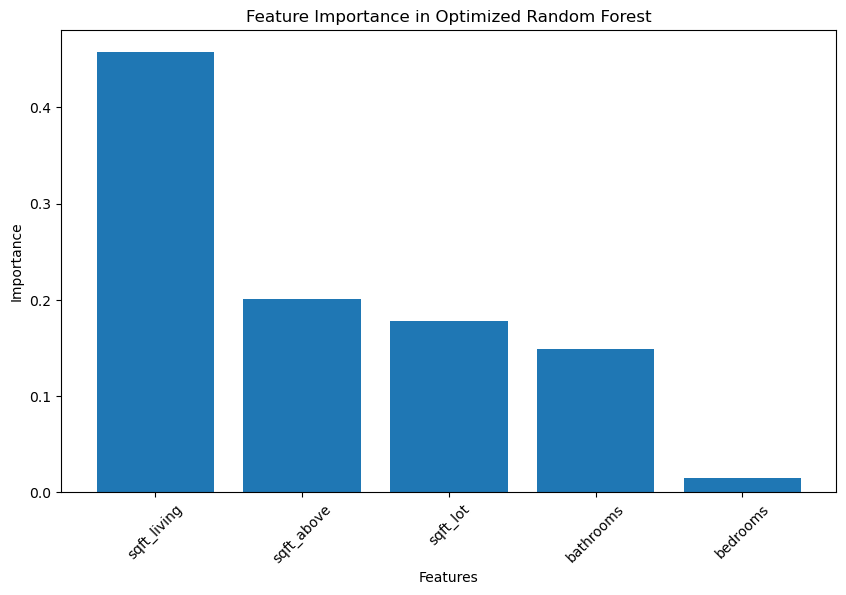

<Figure size 640x480 with 0 Axes>

In [131]:
rfr_importances = rfr_best.feature_importances_
rfr_feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': rfr_feature_names, 'Importance': rfr_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance in Optimized Random Forest')
plt.show()

# Save plot for portfolio
plt.savefig('random_forest_feature_importance.png')